## feature engineering and dataset cleaning

In [29]:
import numpy as np
import pandas as pd
df = pd.read_csv('youtube_cleaned_success_only.csv')
df.head(2)

,video_id,title,channel,channel_id,published,views,likes,thumbnail_url,category_id,subscribers,region,Source.Name
0,F8ZTXYOPRZ4,Do your baby’s hair 🤣#greys #greysanatomy #fyp,Andy Huang,UCy06srAhwzLdsPBC6CiR96A,2025-02-18T06:00:09Z,7378507,438016,https://i.ytimg.com/vi/F8ZTXYOPRZ4/hqdefault.jpg,22,16000,CA,NaN
1,bZVQcBgjfSI,XYL ARP556+Black Bear Tracer.Who needs this fo...,LKCJ,UC_bPnE6C8ucaq7JHPKlaf-Q,2025-02-25T14:50:30Z,2550039,65566,https://i.ytimg.com/vi/bZVQcBgjfSI/hqdefault.jpg,22,5680000,CA,NaN


In [30]:
# 3. Convert that column to datetime
df['published'] = pd.to_datetime(df['published'], format="%Y-%m-%dT%H:%M:%SZ", errors='coerce')

# 4. Extract the date if you need it
df['publish_date'] = df['published'].dt.date

# 5. Extract the hour (0–23) directly
df['publish_hour'] = df['published'].dt.hour

# 6. (Optional) If you really want a time object too:
df['publish_time'] = df['published'].dt.time

# 7. Drop the old Source.Name column
df.drop('Source.Name', axis=1, inplace=True)

df.head()

,video_id,title,channel,channel_id,published,views,likes,thumbnail_url,category_id,subscribers,region,publish_date,publish_hour,publish_time
0,F8ZTXYOPRZ4,Do your baby’s hair 🤣#greys #greysanatomy #fyp,Andy Huang,UCy06srAhwzLdsPBC6CiR96A,2025-02-18 06:00:09,7378507,438016,https://i.ytimg.com/vi/F8ZTXYOPRZ4/hqdefault.jpg,22,16000,CA,2025-02-18,6.0,06:00:09
1,bZVQcBgjfSI,XYL ARP556+Black Bear Tracer.Who needs this fo...,LKCJ,UC_bPnE6C8ucaq7JHPKlaf-Q,2025-02-25 14:50:30,2550039,65566,https://i.ytimg.com/vi/bZVQcBgjfSI/hqdefault.jpg,22,5680000,CA,2025-02-25,14.0,14:50:30
2,WPc3qG3kZnw,How to terminate a Cat7 field termination with...,HY CONNECT,UCYxXK5KWL_Ta6jZ4yzFGVhQ,2025-02-13 08:33:21,1989137,22551,https://i.ytimg.com/vi/WPc3qG3kZnw/hqdefault.jpg,22,12800,CA,2025-02-13,8.0,08:33:21
3,mvWE3inpe6Y,"If you want to eat chicken wings, you can try ...",Chinese Cuisine Official channel,UCY6zyw7X3tMYAN5ZxbrNyog,2025-02-11 12:01:13,173074,3513,https://i.ytimg.com/vi/mvWE3inpe6Y/hqdefault.jpg,26,67000,CA,2025-02-11,12.0,12:01:13
4,mle65DevJQo,Peppa Pig’s New Red Bed | Kids Story Animation,Mushroom,UCcYKDKMq3KMxcpdF9bteFFQ,2025-02-12 04:00:28,13451466,585370,https://i.ytimg.com/vi/mle65DevJQo/hqdefault.jpg,1,4600000,CA,2025-02-12,4.0,04:00:28


In [31]:
df = df.dropna(subset=['published']).reset_index(drop=True)

In [32]:
df.isnull().sum()

video_id         0
title            0
channel          0
channel_id       0
published        0
views            0
likes            0
thumbnail_url    0
category_id      0
subscribers      0
region           0
publish_date     0
publish_hour     0
publish_time     0
dtype: int64

In [33]:
import pandas as pd

# 1. Make sure publish_date is datetime64
df['publish_date'] = pd.to_datetime(df['publish_date'])

# 2. Extract the day name (Monday, Tuesday, …)
df['day_of_week'] = df['publish_date'].dt.day_name()

In [34]:
# 创建一个新列：weekday (工作日) 或 weekend (周末)
df['day_type'] = df['publish_date'].apply(lambda x: 'weekday' if x.weekday() < 5 else 'weekend')
# 定义时间段分类函数
def classify_time_of_day(t):
    hour = t.hour
    if 7 <= hour < 12:
        return 'morning'     # 早上
    elif 12 <= hour < 17:
        return 'afternoon'   # 下午
    elif 17 <= hour < 22:
        return 'evening'     # 晚上
    elif 22 <= hour < 24:
        return 'late evening'     # 晚上
    else:
        return 'other'    # 凌晨（包含 22点 到 第二天早上5点）

# 应用到 publish_time 列
df['time_of_day'] = df['publish_time'].apply(classify_time_of_day)
df

,video_id,title,channel,channel_id,published,views,likes,thumbnail_url,category_id,subscribers,region,publish_date,publish_hour,publish_time,day_of_week,day_type,time_of_day
0,F8ZTXYOPRZ4,Do your baby’s hair 🤣#greys #greysanatomy #fyp,Andy Huang,UCy06srAhwzLdsPBC6CiR96A,2025-02-18 06:00:09,7378507,438016,https://i.ytimg.com/vi/F8ZTXYOPRZ4/hqdefault.jpg,22,16000,CA,2025-02-18,6.0,06:00:09,Tuesday,weekday,other
1,bZVQcBgjfSI,XYL ARP556+Black Bear Tracer.Who needs this fo...,LKCJ,UC_bPnE6C8ucaq7JHPKlaf-Q,2025-02-25 14:50:30,2550039,65566,https://i.ytimg.com/vi/bZVQcBgjfSI/hqdefault.jpg,22,5680000,CA,2025-02-25,14.0,14:50:30,Tuesday,weekday,afternoon
2,WPc3qG3kZnw,How to terminate a Cat7 field termination with...,HY CONNECT,UCYxXK5KWL_Ta6jZ4yzFGVhQ,2025-02-13 08:33:21,1989137,22551,https://i.ytimg.com/vi/WPc3qG3kZnw/hqdefault.jpg,22,12800,CA,2025-02-13,8.0,08:33:21,Thursday,weekday,morning
3,mvWE3inpe6Y,"If you want to eat chicken wings, you can try ...",Chinese Cuisine Official channel,UCY6zyw7X3tMYAN5ZxbrNyog,2025-02-11 12:01:13,173074,3513,https://i.ytimg.com/vi/mvWE3inpe6Y/hqdefault.jpg,26,67000,CA,2025-02-11,12.0,12:01:13,Tuesday,weekday,afternoon
4,mle65DevJQo,Peppa Pig’s New Red Bed | Kids Story Animation,Mushroom,UCcYKDKMq3KMxcpdF9bteFFQ,2025-02-12 04:00:28,13451466,585370,https://i.ytimg.com/vi/mle65DevJQo/hqdefault.jpg,1,4600000,CA,2025-02-12,4.0,04:00:28,Wednesday,weekday,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9903,3DmX7mEp2gY,"Ammayi Garu - Quick Recap - 4 - Apuroopa, Raju...",Zee Telugu,UC3PYGKK29qJ0zu-eEthHK4g,2025-02-22 03:10:00,1377,12,https://i.ytimg.com/vi/3DmX7mEp2gY/hqdefault.jpg,24,16600000,IND,2025-02-22,3.0,03:10:00,Saturday,weekend,other
9904,IHvJWhQhjos,Nindu Noorella Saavasam - Quick Recap - 11 - M...,Zee Telugu,UC3PYGKK29qJ0zu-eEthHK4g,2025-02-24 03:20:00,2236,31,https://i.ytimg.com/vi/IHvJWhQhjos/hqdefault.jpg,24,16600000,IND,2025-02-24,3.0,03:20:00,Monday,weekday,other
9905,2R3fRhGFdIw,Meenakshi Ponnunga - Quick Recap - 26 - Meenak...,Zee Tamil,UC_wIGmvdyAQLtl-U2nHV9rg,2025-02-23 06:00:02,676,3,https://i.ytimg.com/vi/2R3fRhGFdIw/hqdefault.jpg,24,16400000,IND,2025-02-23,6.0,06:00:02,Sunday,weekend,other
9906,Adpmxe2Us4Y,Meenakshi Ponnunga - Quick Recap - 15 - Meenak...,Zee Tamil,UC_wIGmvdyAQLtl-U2nHV9rg,2025-02-22 06:00:11,407,2,https://i.ytimg.com/vi/Adpmxe2Us4Y/hqdefault.jpg,24,16400000,IND,2025-02-22,6.0,06:00:11,Saturday,weekend,other


In [35]:
df_train = df.copy()
df_train = df_train.drop(['published','title', 'channel', 'channel_id', 'publish_date','thumbnail_url', 'publish_time'], axis=1)
df_train.head()

,video_id,views,likes,category_id,subscribers,region,publish_hour,day_of_week,day_type,time_of_day
0,F8ZTXYOPRZ4,7378507,438016,22,16000,CA,6.0,Tuesday,weekday,other
1,bZVQcBgjfSI,2550039,65566,22,5680000,CA,14.0,Tuesday,weekday,afternoon
2,WPc3qG3kZnw,1989137,22551,22,12800,CA,8.0,Thursday,weekday,morning
3,mvWE3inpe6Y,173074,3513,26,67000,CA,12.0,Tuesday,weekday,afternoon
4,mle65DevJQo,13451466,585370,1,4600000,CA,4.0,Wednesday,weekday,other


In [36]:
df_train['like_ratio']=df_train['likes']/df_train['views']
df_train['subscriber_ratio']=df_train['subscribers']/df_train['views']
df_train[['like_ratio', 'subscriber_ratio']] = df_train[['like_ratio', 'subscriber_ratio']].replace([np.inf, -np.inf], np.nan)
df_train[['like_ratio', 'subscriber_ratio']] = df_train[['like_ratio', 'subscriber_ratio']].fillna(0)
df_train['like_ratio'] = df_train['like_ratio'].round(4)
df_train['subscriber_ratio'] = df_train['subscriber_ratio'].round(4)

df_train.head()

,video_id,views,likes,category_id,subscribers,region,publish_hour,day_of_week,day_type,time_of_day,like_ratio,subscriber_ratio
0,F8ZTXYOPRZ4,7378507,438016,22,16000,CA,6.0,Tuesday,weekday,other,0.0594,0.0022
1,bZVQcBgjfSI,2550039,65566,22,5680000,CA,14.0,Tuesday,weekday,afternoon,0.0257,2.2274
2,WPc3qG3kZnw,1989137,22551,22,12800,CA,8.0,Thursday,weekday,morning,0.0113,0.0064
3,mvWE3inpe6Y,173074,3513,26,67000,CA,12.0,Tuesday,weekday,afternoon,0.0203,0.3871
4,mle65DevJQo,13451466,585370,1,4600000,CA,4.0,Wednesday,weekday,other,0.0435,0.3420


In [37]:
df_train.isnull().sum()

video_id            0
views               0
likes               0
category_id         0
subscribers         0
region              0
publish_hour        0
day_of_week         0
day_type            0
time_of_day         0
like_ratio          0
subscriber_ratio    0
dtype: int64

### neural network

#### download package

In [19]:
!pip install tensorflow

#### start model

In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Flatten, Dense, Concatenate
from tensorflow.keras.preprocessing.image import load_img, img_to_array

2025-04-21 20:46:19.155418: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-21 20:46:19.165769: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-21 20:46:19.187232: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745268379.218132   14487 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745268379.227765   14487 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745268379.265820   14487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [38]:
df = df_train.copy()
df

,video_id,views,likes,category_id,subscribers,region,publish_hour,day_of_week,day_type,time_of_day,like_ratio,subscriber_ratio
0,F8ZTXYOPRZ4,7378507,438016,22,16000,CA,6.0,Tuesday,weekday,other,0.0594,0.0022
1,bZVQcBgjfSI,2550039,65566,22,5680000,CA,14.0,Tuesday,weekday,afternoon,0.0257,2.2274
2,WPc3qG3kZnw,1989137,22551,22,12800,CA,8.0,Thursday,weekday,morning,0.0113,0.0064
3,mvWE3inpe6Y,173074,3513,26,67000,CA,12.0,Tuesday,weekday,afternoon,0.0203,0.3871
4,mle65DevJQo,13451466,585370,1,4600000,CA,4.0,Wednesday,weekday,other,0.0435,0.3420
...,...,...,...,...,...,...,...,...,...,...,...,...
9903,3DmX7mEp2gY,1377,12,24,16600000,IND,3.0,Saturday,weekend,other,0.0087,12055.1924
9904,IHvJWhQhjos,2236,31,24,16600000,IND,3.0,Monday,weekday,other,0.0139,7423.9714
9905,2R3fRhGFdIw,676,3,24,16400000,IND,6.0,Sunday,weekend,other,0.0044,24260.3550
9906,Adpmxe2Us4Y,407,2,24,16400000,IND,6.0,Saturday,weekend,other,0.0049,40294.8403


In [39]:
# 3. Build image tensor
IMG_SIZE = (128, 128)
def load_image(video_id):
    path = f'youtube_thumbnails/{video_id}.jpg'
    try:
        img = load_img(path, target_size=IMG_SIZE)
        return img_to_array(img) / 255.0
    except:
        return np.zeros((*IMG_SIZE, 3))

image_tensor = np.stack(df['video_id'].apply(load_image).values)  # shape = (N,128,128,3)

In [40]:
# 4. Prepare tabular features
tab_df = df.drop(columns=['video_id', 'views'])

# 把所有字符串类型的 categorical 列都进行 one-hot 编码
tab_df = pd.get_dummies(
    tab_df,
    columns=['region', 'day_of_week', 'day_type', 'time_of_day'],  # 👈 加上所有非数值列
    drop_first=True
)

scaler = StandardScaler()
X_tabular = scaler.fit_transform(tab_df)  # ✅ 现在可以标准化了

In [41]:
# log(1 + views) 缩放到更合理区间
y = np.log1p(df['views'].values)

# 6. Train/validation split
X_img_train, X_img_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
    image_tensor, X_tabular, y, test_size=0.2, random_state=42
)

In [42]:
# 7. Build a very simple multi‑input model
#    (MODIFIED: Flatten image → Dense instead of Conv2D stack)

# Image branch
img_input = Input(shape=(128,128,3), name='image_input')
x = Flatten()(img_input)
x = Dense(32, activation='relu')(x)           # image embedding

# Tabular branch
tab_input = Input(shape=(X_tabular.shape[1],), name='tabular_input')
t = Dense(32, activation='relu')(tab_input)   # tabular embedding

# Merge & output
combined = Concatenate()([x, t])
z = Dense(16, activation='relu')(combined)
output = Dense(1, activation='linear')(z)     # regression output

# Create & compile
model = Model(inputs=[img_input, tab_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

2025-04-21 20:54:11.232777: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 49152)     │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │  1,572,896 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        672 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │      1,040 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,574,625 (6.01 MB)

 Trainable params: 1,574,625 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = model.fit(
    [X_img_train, X_tab_train],
    y_train,
    validation_data=([X_img_val, X_tab_val], y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20


2025-04-21 20:54:15.360507: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1558315008 exceeds 10% of free system memory.


248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 25.5042 - mae: 3.8844 - val_loss: 14.5419 - val_mae: 3.0477
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 11.7596 - mae: 2.6725 - val_loss: 8.2764 - val_mae: 2.1704
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.0560 - mae: 1.9952 - val_loss: 6.9426 - val_mae: 2.0095
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.0356 - mae: 1.6441 - val_loss: 5.8011 - val_mae: 1.7091
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.5098 - mae: 1.5074 - val_loss: 5.5851 - val_mae: 1.6310
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.0586 - mae: 1.4285 - val_loss: 5.8395 - val_mae: 1.6357
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.7256 - mae: 1.3942 - val_loss: 5.1868 - val_mae: 1.6091
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.6779 - mae: 1.3904 - val_loss: 4.8461 - val_mae: 1.4666
Epoch 9/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - los

### evaluate performance

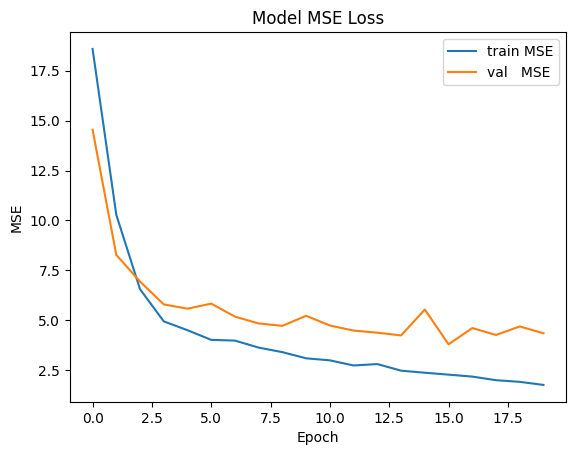

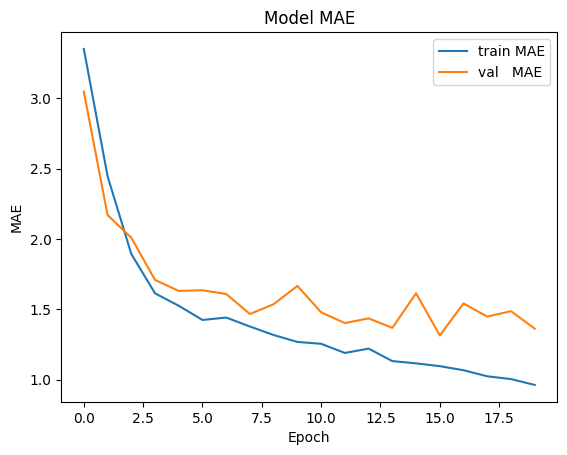

In [44]:
import matplotlib.pyplot as plt

# Loss (MSE) curve
plt.plot(history.history['loss'],    label='train MSE')
plt.plot(history.history['val_loss'],label='val   MSE')
plt.title("Model MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

# MAE curve
plt.plot(history.history['mae'],     label='train MAE')
plt.plot(history.history['val_mae'], label='val   MAE')
plt.title("Model MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

In [45]:
val_mse, val_mae = model.evaluate(
    [X_img_val, X_tab_val],
    y_val,
    batch_size=32,
    verbose=1
)
print(f"Validation MSE = {val_mse:.2f}")
print(f"Validation MAE = {val_mae:.2f}")


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3957 - mae: 1.3537
Validation MSE = 4.36
Validation MAE = 1.36


In [46]:
from sklearn.metrics import r2_score

y_pred_log = model.predict([X_img_val, X_tab_val]).flatten()
r2_log = r2_score(y_val, y_pred_log)
print(f"R² (log1p) = {r2_log:.3f}")


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R² (log1p) = 0.538
